In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch, coherence, csd, get_window
from scipy.fft import fft, ifft
import pandas as pd
import os
import matplotlib.gridspec as gridspec

# --- (必要なら) Google Drive ---
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Caffe用の顔検出モデルをダウンロード
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt -O deploy.prototxt
!wget https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel -O res10_300x300_ssd_iter_140000.caffemodel

--2025-11-10 12:04:06--  https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28104 (27K) [text/plain]
Saving to: ‘deploy.prototxt’

deploy.prototxt     100%[===================>]  27.45K  --.-KB/s    in 0.004s  

2025-11-10 12:04:06 (7.02 MB/s) - ‘deploy.prototxt’ saved [28104/28104]

--2025-11-10 12:04:06--  https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_s

FPS=24.00, size=(1080x1920), frames=723


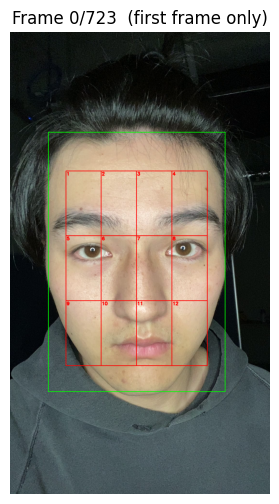

ROIデバッグ動画を保存しました: /content/roi_debug.mp4


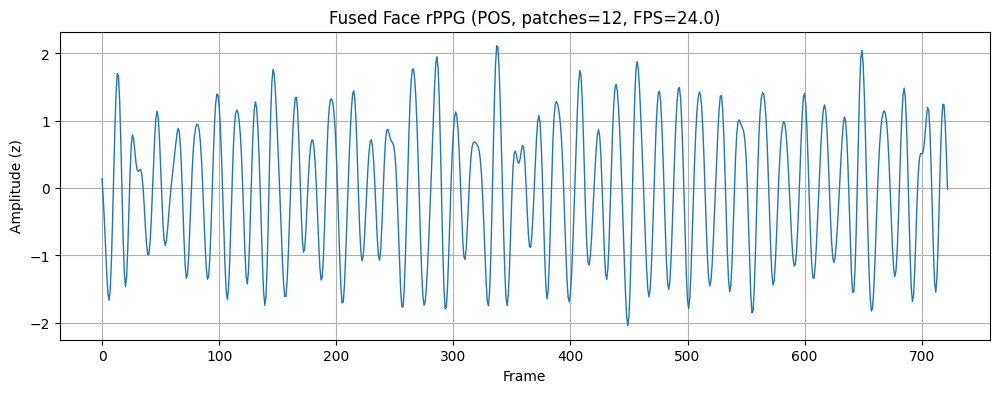

Saved: /content/drive/Shareddrives/MuraolabExchange-6th/Taiki Yuma/研究/DMD_mode/test_data/movie_B02_face_ppg.csv


In [ ]:
# ===== ユーザー設定 =====
BASE_DIR = "/content/drive/Shareddrives/MuraolabExchange-6th/Taiki Yuma/研究/DMD_mode/movie"
file = "movie_B02.mov"
video_path = os.path.join(BASE_DIR, file)

FINGER_PPG_PATH = None  # 例: "/content/drive/MyDrive/finger_ppg.csv"
USE_CHROM = False

LOW_HZ, HIGH_HZ = 0.7, 2.5
WIN_SEC = 1
HOP_SEC = 0.1
COH_BW = (0.7, 4)
MAX_LAG_SEC = 0.24

# ==== 追加: ROI可視化の設定 ====
DRAW_AND_SHOW_ROI = True     # Matplotlibでプレビュー表示
SHOW_EVERY_N = 24            # 何フレームごとに表示するか（例: 30なら約1秒に1回）
SAVE_DEBUG_VIDEO = True      # ROI枠を書き込んだデバッグ動画を保存
DEBUG_VID_PATH = "/content/roi_debug.mp4"
DEBUG_VID_FPS = None         # Noneなら入力動画のFPSを使用
ROI_RECT_COLOR = (0, 0, 255) # BGR (赤)
FACE_RECT_COLOR = (0, 255, 0)# BGR (緑)
RECT_THICK = 2

# ===== ユーティリティ =====
def bandpass_butter(x, fs, low=0.7, high=1.7, order=3):
    if x is None or len(x) == 0:
        return x
    nyq = 0.5 * fs
    low_n = max(1e-6, low / nyq)
    high_n = min(0.999, high / nyq)
    b, a = butter(order, [low_n, high_n], btype='band')
    return filtfilt(b, a, x)

def pos_project(rgb_mat):
    X = (rgb_mat - np.mean(rgb_mat, axis=0, keepdims=True)) / (np.std(rgb_mat, axis=0, keepdims=True) + 1e-8)
    R, G, B = X[:,0], X[:,1], X[:,2]
    Xc = 3*R - 2*G
    Yc = 1.5*R + G - 1.5*B
    alpha = (np.std(Xc) + 1e-8) / (np.std(Yc) + 1e-8)
    return Xc - alpha * Yc

def chrom_project(rgb_mat):
    X = (rgb_mat - np.mean(rgb_mat, axis=0, keepdims=True)) / (np.std(rgb_mat, axis=0, keepdims=True) + 1e-8)
    R, G, B = X[:,0], X[:,1], X[:,2]
    Xc = 0.77*R - 0.51*G
    Yc = 0.77*R + 0.51*G - 0.77*B
    alpha = (np.std(Xc) + 1e-8) / (np.std(Yc) + 1e-8)
    return Xc - alpha * Yc

def sliding_projection_rgb(rgb_seq, fs, win_sec=1.6, hop_sec=0.2, method='POS'):
    T = rgb_seq.shape[0]
    win = int(round(win_sec * fs))
    hop = int(round(hop_sec * fs))
    win = max(win, 8); hop = max(hop, 1)

    from scipy.signal import get_window
    w = get_window('hann', win, fftbins=True)
    out = np.zeros(T, dtype=np.float32)
    wsum = np.zeros(T, dtype=np.float32)

    proj_fn = pos_project if method.upper()=='POS' else chrom_project

    for start in range(0, T - win + 1, hop):
        seg = rgb_seq[start:start+win, :]
        s = proj_fn(seg)
        s = (s - np.mean(s)) / (np.std(s) + 1e-8)
        out[start:start+win] += s * w
        wsum[start:start+win] += w

    nz = wsum > 1e-6
    out[nz] /= wsum[nz]
    if not np.all(nz):
        out[~nz] = np.interp(np.flatnonzero(~nz), np.flatnonzero(nz), out[nz])
    return out

def gcc_phat(x, y, fs, max_lag_sec=0.3):
    n = 1; L = len(x) + len(y)
    while n < L: n *= 2
    X = fft(x, n); Y = fft(y, n)
    R = X * np.conj(Y); R /= (np.abs(R) + 1e-12)
    cc = np.real(ifft(R))
    cc = np.concatenate((cc[-(n//2):], cc[:n//2]))
    lags = np.arange(-n//2, n//2) / fs
    mask = (np.abs(lags) <= max_lag_sec)
    cc_m = cc[mask]; lags_m = lags[mask]
    k = np.argmax(cc_m)
    if 0 < k < len(cc_m)-1:
        y0, y1, y2 = cc_m[k-1], cc_m[k], cc_m[k+1]
        denom = (2*(y0 - 2*y1 + y2) + 1e-12)
        delta = (y0 - y2) / denom
        tau = lags_m[k] + (delta / (2*fs))
    else:
        tau = lags_m[k]
    return float(tau)

from scipy.signal import coherence
def ms_coherence(x, y, fs, band=(0.7,1.7)):
    f, Cxy = coherence(x, y, fs=fs, nperseg=min(len(x), 256))
    idx = (f >= band[0]) & (f <= band[1])
    if np.sum(idx) < 2: return 0.0
    return float(np.mean(Cxy[idx]))

# ===== 顔検出準備 =====
prototxt = 'deploy.prototxt'
model = 'res10_300x300_ssd_iter_140000.caffemodel'
net = cv2.dnn.readNetFromCaffe(prototxt, model)

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"動画を開けませんでした: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS); fps = float(fps) if fps and fps > 0 else 30.0
W  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); H  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
N  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"FPS={fps:.2f}, size=({W}x{H}), frames={N}")

# ---- 初期フレームで顔検出 ----
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ok, frame0 = cap.read()
if not ok:
    cap.release(); raise RuntimeError("最初のフレーム読込に失敗")

h0, w0 = frame0.shape[:2]
blob = cv2.dnn.blobFromImage(cv2.resize(frame0, (300, 300)), 1.0, (300, 300), (104.0,177.0,123.0))
net.setInput(blob)
dets = net.forward()

face_box = None
for i in range(dets.shape[2]):
    conf = dets[0,0,i,2]
    if conf > 0.5:
        box = dets[0,0,i,3:7] * np.array([w0,h0,w0,h0])
        (sx,sy,ex,ey) = box.astype(int)
        face_box = (max(0,sx), max(0,sy), min(w0,ex), min(h0,ey))
        break
if face_box is None:
    cap.release(); raise RuntimeError("顔が検出できませんでした")

fx1, fy1, fx2, fy2 = face_box
fw, fh = fx2 - fx1, fy2 - fy1

# マルチROI設定
GRID_X, GRID_Y = 4, 3
margin_y_top, margin_y_bottom, margin_x_side = 0.15, 0.10, 0.10

# ===== デバッグ動画の準備 =====
writer = None
if SAVE_DEBUG_VIDEO:
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_fps = fps if DEBUG_VID_FPS is None else float(DEBUG_VID_FPS)
    writer = cv2.VideoWriter(DEBUG_VID_PATH, fourcc, out_fps, (W, H))

# ===== 走査：各フレームでROIを描画＆RGB平均を蓄積 =====
rgb_traces = [ [] for _ in range(GRID_X*GRID_Y) ]

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
for t in range(N):
    ok, frame = cap.read()
    if not ok: break

    # 顔ボックスは固定（必要なら再検出を追加）
    x1, y1, x2, y2 = fx1, fy1, fx2, fy2
    fh_now, fw_now = (y2 - y1), (x2 - x1)

    mx1 = int(x1 + margin_x_side * fw_now)
    mx2 = int(x2 - margin_x_side * fw_now)
    my1 = int(y1 + margin_y_top * fh_now)
    my2 = int(y2 - margin_y_bottom * fh_now)

    rw, rh = mx2 - mx1, my2 - my1
    if rw <= 10 or rh <= 10:
        # 小さすぎたらスキップ
        for idx in range(GRID_X*GRID_Y):
            rgb_traces[idx].append([np.nan, np.nan, np.nan])
        continue

    # デバッグ描画用にコピー
    dbg = frame.copy()
    # 顔枠
    cv2.rectangle(dbg, (x1, y1), (x2, y2), FACE_RECT_COLOR, RECT_THICK)

    idx = 0
    for gy in range(GRID_Y):
        for gx in range(GRID_X):
            px1 = mx1 + int(gx   * rw / GRID_X)
            px2 = mx1 + int((gx+1)* rw / GRID_X)
            py1 = my1 + int(gy   * rh / GRID_Y)
            py2 = my1 + int((gy+1)* rh / GRID_Y)
            patch = frame[py1:py2, px1:px2]  # BGR

            # ROI矩形を描画
            cv2.rectangle(dbg, (px1, py1), (px2, py2), ROI_RECT_COLOR, RECT_THICK)
            # インデックス（任意）
            cv2.putText(dbg, f"{idx+1}", (px1+3, py1+18), cv2.FONT_HERSHEY_SIMPLEX, 0.6, ROI_RECT_COLOR, 2, cv2.LINE_AA)

            # RGB平均
            if patch.size == 0:
                rgb_traces[idx].append([np.nan, np.nan, np.nan])
            else:
                b,g,r = patch.reshape(-1,3).mean(axis=0)
                rgb_traces[idx].append([r,g,b])
            idx += 1

    # ---- 表示（最初のフレームだけ） ----
    if DRAW_AND_SHOW_ROI and t == 0:
        plt.figure(figsize=(8,6))
        plt.imshow(cv2.cvtColor(dbg, cv2.COLOR_BGR2RGB))
        plt.title(f"Frame {t}/{N}  (first frame only)")
        plt.axis('off'); plt.show()


    # ---- 動画保存 ----
    if writer is not None:
        writer.write(dbg)

cap.release()
if writer is not None:
    writer.release()
    print("ROIデバッグ動画を保存しました:", DEBUG_VID_PATH)

# ndarray化＆欠損補間
rgb_traces = [ np.array(tr, dtype=np.float32) for tr in rgb_traces ]
T = min(tr.shape[0] for tr in rgb_traces if tr.size>0)
rgb_traces = [ tr[:T] for tr in rgb_traces ]
for i,tr in enumerate(rgb_traces):
    if np.isnan(tr).any():
        for c in range(3):
            x = tr[:,c]
            nzi = np.where(~np.isnan(x))[0]
            if len(nzi) >= 2:
                tr[:,c] = np.interp(np.arange(len(x)), nzi, x[nzi])
            elif len(nzi)==1:
                tr[:,c] = x[nzi[0]]
            else:
                tr[:,c] = 0
        rgb_traces[i] = tr

# POS/CHROM → BPF → 正規化
method = 'CHROM' if USE_CHROM else 'POS'
ppg_patches = []
for tr in rgb_traces:
    s = sliding_projection_rgb(tr, fs=fps, win_sec=WIN_SEC, hop_sec=HOP_SEC, method=method)
    s = bandpass_butter(s, fs=fps, low=LOW_HZ, high=HIGH_HZ, order=3)
    s = (s - np.mean(s)) / (np.std(s)+1e-8)
    ppg_patches.append(s)
ppg_patches = np.array(ppg_patches)  # (P, T)

# 指PPGがあれば読み込み
if FINGER_PPG_PATH and os.path.exists(FINGER_PPG_PATH):
    finger = pd.read_csv(FINGER_PPG_PATH, header=None).values.squeeze()
    L = min(len(finger), ppg_patches.shape[1])
    finger = finger[:L].astype(np.float32)
    ppg_patches = ppg_patches[:, :L]
    ref_sig = bandpass_butter(finger, fs=fps, low=LOW_HZ, high=HIGH_HZ, order=3)
    ref_sig = (ref_sig - np.mean(ref_sig))/ (np.std(ref_sig)+1e-8)
else:
    ref_sig = np.mean(ppg_patches, axis=0)
    ref_sig = (ref_sig - np.mean(ref_sig))/ (np.std(ref_sig)+1e-8)

# コヒーレンスを重み化
weights = []
for p in range(ppg_patches.shape[0]):
    w = ms_coherence(ppg_patches[p], ref_sig, fs=fps, band=COH_BW)
    weights.append(w)
weights = np.array(weights, dtype=np.float32) + 1e-6
weights /= np.sum(weights)

# 合成rPPG
face_ppg_fused = np.sum(ppg_patches * weights[:,None], axis=0)
face_ppg_fused = (face_ppg_fused - np.mean(face_ppg_fused)) / (np.std(face_ppg_fused)+1e-8)

# 可視化
plt.figure(figsize=(12,4))
plt.plot(face_ppg_fused, lw=1)
plt.title(f"Fused Face rPPG ({method}, patches={ppg_patches.shape[0]}, FPS={fps:.1f})")
plt.xlabel("Frame"); plt.ylabel("Amplitude (z)")
plt.grid(True); plt.show()

# 保存
TEST_DIR = "/content/drive/Shareddrives/MuraolabExchange-6th/Taiki Yuma/研究/DMD_mode/test_data"
os.makedirs(TEST_DIR, exist_ok=True)

base_name = os.path.splitext(os.path.basename(video_path))[0]   # 例: movie_B
out_name  = f"{base_name}_face_ppg.csv"                          # 例: movie_B_face_ppg.csv
save_path = os.path.join(TEST_DIR, out_name)

np.savetxt(save_path, face_ppg_fused, delimiter=",")
print("Saved:", save_path)

Video Path: /content/drive/Shareddrives/MuraolabExchange-6th/Taiki Yuma/研究/DMD_mode/movie/movie_A01.mov
FPS: 24.00, Frames: 708, Size: 1080x1920


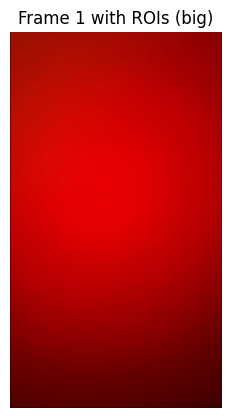

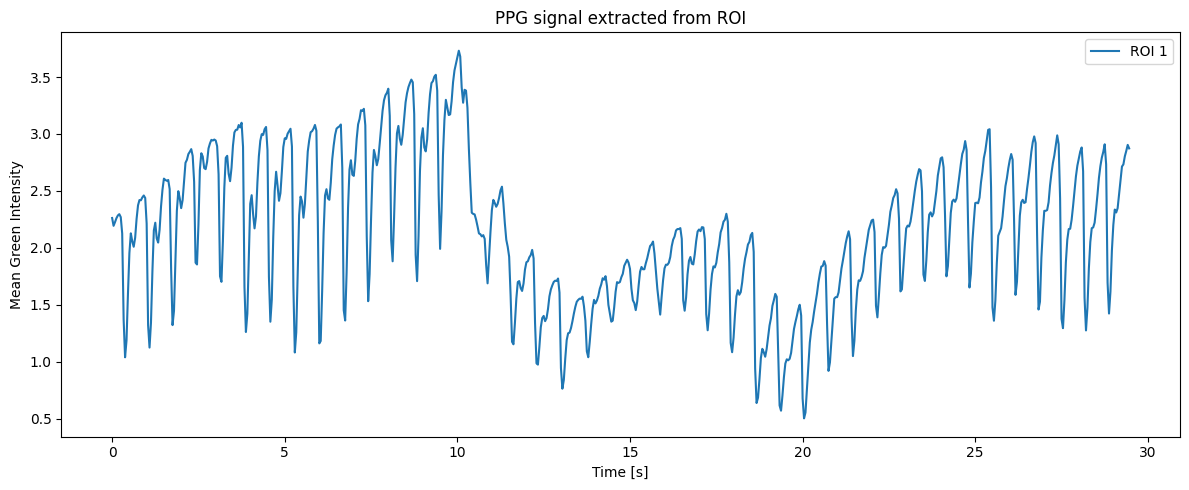

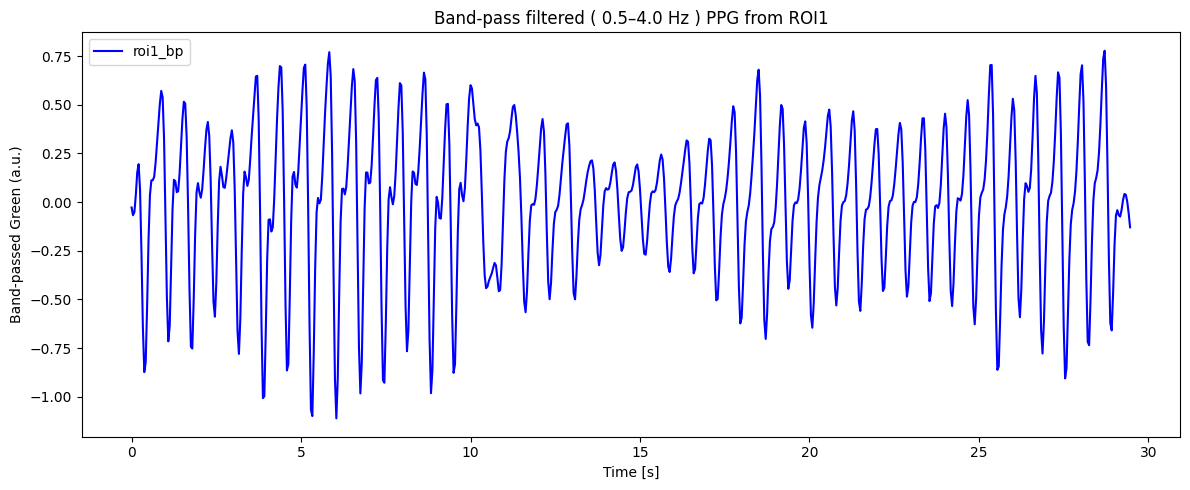

保存しました: /content/drive/Shareddrives/MuraolabExchange-6th/Taiki Yuma/研究/DMD_mode/test_data/movie_A01_finger_ppg.csv


In [ ]:
# ====== パス設定 ======
BASE_DIR = "/content/drive/Shareddrives/MuraolabExchange-6th/Taiki Yuma/研究/DMD_mode/movie"
file = "movie_A02.mov"
video_path = os.path.join(BASE_DIR, file)

# ====== ROI（フレーム左上基準の絶対座標） ======
regions = [
    {'shift_x': 0, 'shift_y': 0, 'width': 1080, 'height': 1920},
]

# ====== ユーティリティ ======
def clamp_rect(x, y, w, h, W, H):
    x = max(0, min(int(x), W-1))
    y = max(0, min(int(y), H-1))
    x2 = max(0, min(x + int(w), W))
    y2 = max(0, min(y + int(h), H))
    return x, y, x2 - x, y2 - y

# ====== 動画読み込み・基本情報 ======
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"動画を開けません: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"Video Path: {video_path}")
print(f"FPS: {fps:.2f}, Frames: {num_frames}, Size: {W}x{H}")

# ====== 1フレーム目 ======
ret, first_frame = cap.read()
cap.release()
if not ret:
    raise RuntimeError("最初のフレームを取得できませんでした。")

# ====== ★ regions -> rois を毎回再計算 ★ ======
rois = []
for r in regions:
    x, y, w, h = r['shift_x'], r['shift_y'], r['width'], r['height']
    x, y, w, h = clamp_rect(x, y, w, h, W, H)
    rois.append((x, y, w, h))

# ====== 可視化（上：大フレーム、下：小サムネ） ======
vis = first_frame.copy()
for (x, y, w, h) in rois:
    cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 0, 0), 2)

cols = max(len(rois), 1)
fig = plt.figure(figsize=(12, 7))
gs = gridspec.GridSpec(nrows=2, ncols=cols, height_ratios=[3, 1], hspace=0.15, wspace=0.0)

# 最初のフレーム
ax_main = fig.add_subplot(gs[0, :])
ax_main.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
ax_main.set_title("Frame 1 with ROIs (big)")
ax_main.axis("off")

plt.show()

# ====== ROIからG値を抽出 ======
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"動画を開けません: {video_path}")

roi_signals = {f"roi{i+1}": [] for i in range(len(rois))}
time_list = []
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    g = frame[:, :, 1]  # BGR → Gチャネル

    for i, (x, y, w, h) in enumerate(rois):
        patch = g[y:y+h, x:x+w]
        roi_signals[f"roi{i+1}"].append(float(patch.mean()))

    time_list.append(frame_idx / fps if fps > 0 else frame_idx)
    frame_idx += 1

cap.release()

# # ====== DataFrame化 ======
df = pd.DataFrame({"time_sec": time_list, **roi_signals})

# ====== プロット ======
plt.figure(figsize=(12,5))
for i in range(len(rois)):
    plt.plot(df["time_sec"], df[f"roi{i+1}"], label=f"ROI {i+1}")
plt.xlabel("Time [s]")
plt.ylabel("Mean Green Intensity")
plt.title("PPG signal extracted from ROI")
plt.legend()
plt.tight_layout()
plt.show()

# サンプリング周波数（動画FPS）
fs = float(fps) if 'fps' in locals() else 30.0

# 帯域
LOW_HZ, HIGH_HZ = 0.5, 4  # :contentReference[oaicite:1]{index=1}

def bandpass_butter(x, fs, low, high, order=3):
    nyq = 0.5 * fs
    low_n = low / nyq
    high_n = high / nyq
    b, a = butter(order, [low_n, high_n], btype='band')
    return filtfilt(b, a, x)

# 前セルで df を作っていない場合に備えて作成
if 'df' not in locals():
    df = pd.DataFrame({"time_sec": time_list, **roi_signals})

# 各 ROI にフィルタを適用（平均差し引き→NaN対策→filtfilt）
filtered_cols = []
for col in [c for c in df.columns if c.startswith("roi")]:
    x = np.asarray(df[col], dtype=float)
    x = x - np.nanmean(x)
    x = np.nan_to_num(x)  # NaN, inf を 0 に
    y = bandpass_butter(x, fs=fs, low=LOW_HZ, high=HIGH_HZ, order=3)
    df[col + "_bp"] = y
    filtered_cols.append(col + "_bp")

# ====== プロット ======
plt.figure(figsize=(12,5))

# 先頭のROI（roi1_bp）だけを描画
first_col = filtered_cols[0]
plt.plot(df["time_sec"], df[first_col], color="blue", label=first_col)

plt.xlabel("Time [s]")
plt.ylabel("Band-passed Green (a.u.)")
plt.title(f"Band-pass filtered ( {LOW_HZ:.1f}–{HIGH_HZ:.1f} Hz ) PPG from ROI1")
plt.legend()
plt.tight_layout()
plt.show()

# ====== CSV 保存 ======
out_dir = "/content/drive/Shareddrives/MuraolabExchange-6th/Taiki Yuma/研究/DMD_mode/test_data"
os.makedirs(out_dir, exist_ok=True)

# "動画ファイル名_finger_ppg.csv" 形式で保存
csv_path = os.path.join(out_dir, f"{os.path.splitext(file)[0]}_finger_ppg.csv")

# time_sec と先頭ROIのバンドパス信号だけを保存
df_out = df[["time_sec", first_col]]
df_out.to_csv(csv_path, index=False, encoding="utf-8")

print("保存しました:", csv_path)

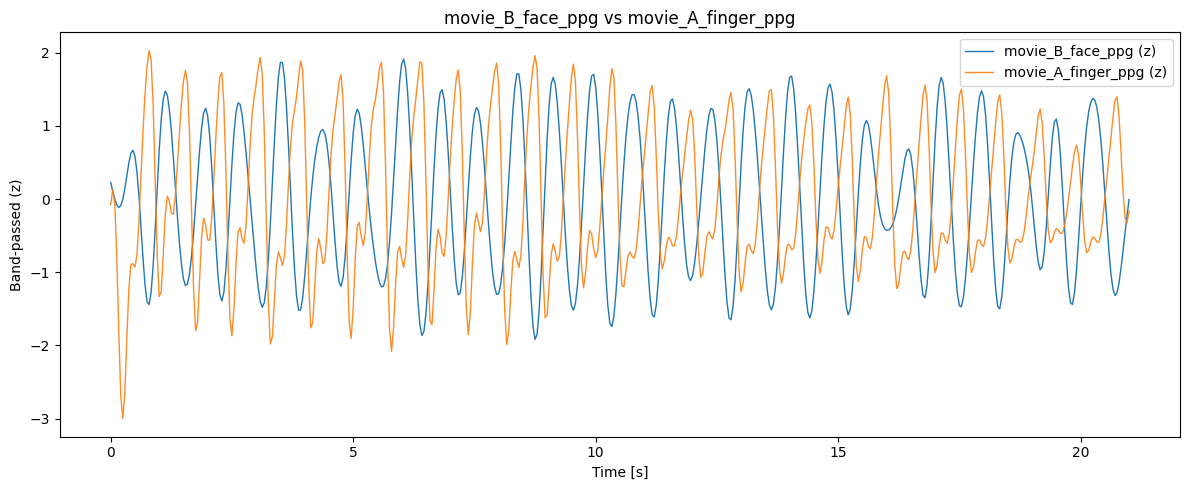

In [ ]:
TEST_DIR = "/content/drive/Shareddrives/MuraolabExchange-6th/Taiki Yuma/研究/DMD_mode/test_data"

# ファイルパス（手動で movie_B と movie_A を指定）
FACE_CSV = os.path.join(TEST_DIR, "movie_B2_face_ppg.csv")     # 1列 (np.savetxtで保存)
FING_CSV = os.path.join(TEST_DIR, "movie_A2_finger_ppg.csv")   # 2列 (time_sec, value)

# ---- 顔 (movie_B) の読み込み ----
face_arr = pd.read_csv(FACE_CSV, header=None).values.squeeze().astype(float)
face_z = (face_arr - np.mean(face_arr)) / (np.std(face_arr) + 1e-8)

# 顔の時間軸（動画fpsと同じと仮定）
CSV_FS = float(fps) if fps and fps > 0 else 30.0
t_face = np.arange(len(face_z)) / CSV_FS

# ---- 指 (movie_A) の読み込み ----
df_fing = pd.read_csv(FING_CSV)
t_fing = df_fing.iloc[:, 0].values.astype(float)   # time_sec
y_fing = df_fing.iloc[:, 1].values.astype(float)   # bandpass済み値
y_fing_z = (y_fing - np.mean(y_fing)) / (np.std(y_fing) + 1e-8)

# ---- 長さを揃える（短い方に合わせる）----
L = min(len(face_z), len(y_fing_z))
t_plot = t_face[:L]       # 顔の時間軸を採用（fpsでサンプリングしたもの）
face_plot = face_z[:L]
fing_plot = y_fing_z[:L]

# ---- 描画 ----
plt.figure(figsize=(12,5))
plt.plot(t_plot, face_plot, label="movie_B_face_ppg (z)", linewidth=1.0)
plt.plot(t_plot, fing_plot, label="movie_A_finger_ppg (z)", linewidth=1.0, alpha=0.9)
plt.xlabel("Time [s]")
plt.ylabel("Band-passed (z)")
plt.title("movie_B_face_ppg vs movie_A_finger_ppg")
plt.legend()
plt.tight_layout()
plt.show()

推定サンプリング周波数 fs ≈ 83.333 Hz（中央値ベース）


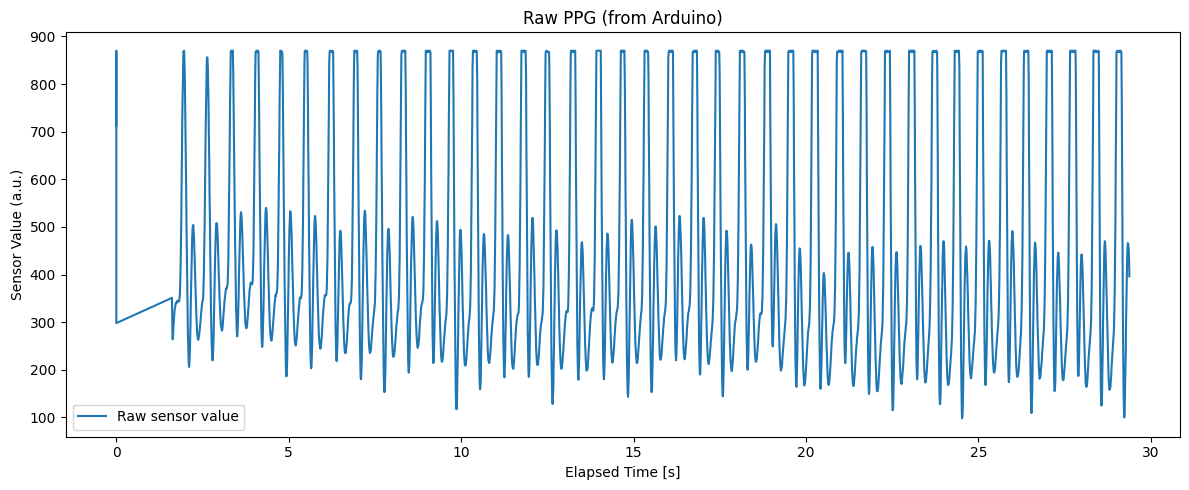

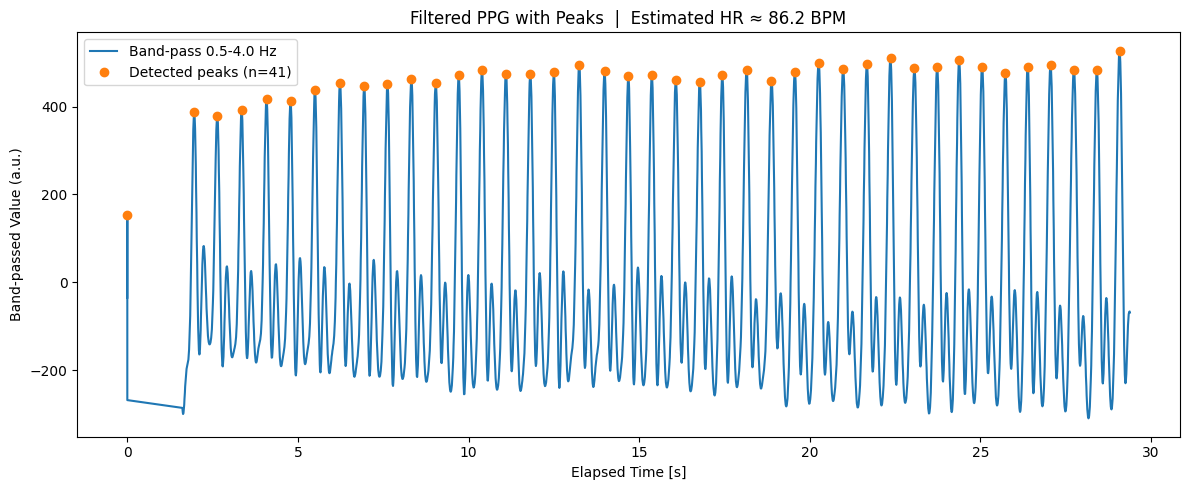

保存しました：
  - /content/drive/Shareddrives/MuraolabExchange-6th/Taiki Yuma/研究/DMD_mode/test_data/ppg_outputs/PPG_data_01_filtered.csv
  - /content/drive/Shareddrives/MuraolabExchange-6th/Taiki Yuma/研究/DMD_mode/test_data/ppg_outputs/PPG_data_01_peaks.csv


In [ ]:
# ====== 必要ライブラリ ======
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# ====== パス設定 ======
BASE_DIR = "/content/drive/Shareddrives/MuraolabExchange-6th/Taiki Yuma/研究/DMD_mode/test_data"
  # カレントディレクトリ（必要なら絶対パスに変更）
file = "PPG_data_01.csv"
csv_path = os.path.join(BASE_DIR, file)

# ====== ユーティリティ ======
def bandpass_butter(x, fs, low=0.5, high=4.0, order=3):
    """
    0.5–4 Hz のゼロ位相 Butterworth バンドパス（filtfilt）
    x: 1次元信号
    fs: サンプリング周波数[Hz]
    """
    if fs <= 0:
        return x
    nyq = 0.5 * fs
    low_n = max(1e-6, low / nyq)
    high_n = min(0.999, high / nyq)
    b, a = butter(order, [low_n, high_n], btype='band')
    return filtfilt(b, a, x)

def robust_fs(t):
    """
    経過時間配列 t（秒）からサンプリング周波数を推定
    外れ値を避けるため、時間差の中央値を使用
    """
    dt = np.diff(t)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if dt.size == 0:
        return 0.0
    return 1.0 / np.median(dt)

# ====== 読み込み ======
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"CSV が見つかりません: {csv_path}")

df = pd.read_csv(csv_path)

# 列名の正規化（大文字・小文字やスペースの違いに強くする）
cols = {c.lower().strip(): c for c in df.columns}
t_col = cols.get("elapsed_time_sec", None)
v_col = cols.get("sensor_value", None)

if t_col is None or v_col is None:
    raise ValueError(f"CSV に必要な列がありません。見つかった列: {list(df.columns)}\n"
                     f"必要: elapsed_time_sec, sensor_value")

# 数値化（文字列で保存されている場合に備える）
t = pd.to_numeric(df[t_col], errors="coerce").to_numpy()
x_raw = pd.to_numeric(df[v_col], errors="coerce").to_numpy()

# 欠損の除去
mask = np.isfinite(t) & np.isfinite(x_raw)
t = t[mask]
x_raw = x_raw[mask]

# ====== サンプリング周波数（Hz）を推定 ======
fs = robust_fs(t)
print(f"推定サンプリング周波数 fs ≈ {fs:.3f} Hz（中央値ベース）")

# ====== フィルタリング ======
LOW_HZ, HIGH_HZ = 0.5, 4.0
x_detrend = x_raw - np.nanmean(x_raw)
x_bp = bandpass_butter(x_detrend, fs=fs, low=LOW_HZ, high=HIGH_HZ, order=3)

# ====== ピーク検出（BPM推定） ======
# 心拍は 0.5–4 Hz 付近なので、最小間隔は ~0.25〜0.4秒程度が目安
min_dist_sec = 0.4
min_dist_samples = int(max(1, np.floor(min_dist_sec * fs)))
peaks, props = find_peaks(x_bp, distance=min_dist_samples, prominence=np.std(x_bp) * 0.3)

bpm = None
if peaks.size >= 2:
    ibi = np.diff(t[peaks])  # Inter-Beat Interval [s]
    ibi = ibi[np.isfinite(ibi) & (ibi > 0)]
    if ibi.size > 0:
        bpm = 60.0 / np.median(ibi)

# ====== プロット ======
plt.figure(figsize=(12, 5))
plt.plot(t, x_raw, label="Raw sensor value")
plt.xlabel("Elapsed Time [s]")
plt.ylabel("Sensor Value (a.u.)")
plt.title("Raw PPG (from Arduino)")
plt.tight_layout()
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(t, x_bp, label=f"Band-pass {LOW_HZ:.1f}-{HIGH_HZ:.1f} Hz")
if peaks.size > 0:
    plt.plot(t[peaks], x_bp[peaks], "o", label=f"Detected peaks (n={len(peaks)})")
title_txt = "Filtered PPG with Peaks"
if bpm is not None:
    title_txt += f"  |  Estimated HR ≈ {bpm:.1f} BPM"
plt.title(title_txt)
plt.xlabel("Elapsed Time [s]")
plt.ylabel("Band-passed Value (a.u.)")
plt.legend()
plt.tight_layout()
plt.show()

# ====== フィルタ済み＆ピーク情報のCSV保存（任意） ======
out_dir = os.path.join(BASE_DIR, "ppg_outputs")
os.makedirs(out_dir, exist_ok=True)
df_out = pd.DataFrame({
    "elapsed_time_sec": t,
    "sensor_value_raw": x_raw,
    "sensor_value_bp": x_bp
})
out_csv = os.path.join(out_dir, f"{os.path.splitext(file)[0]}_filtered.csv")
df_out.to_csv(out_csv, index=False, encoding="utf-8")

peaks_csv = os.path.join(out_dir, f"{os.path.splitext(file)[0]}_peaks.csv")
pd.DataFrame({"peak_time_sec": t[peaks], "peak_value": x_bp[peaks]}).to_csv(
    peaks_csv, index=False, encoding="utf-8"
)

print("保存しました：")
print("  -", out_csv)
print("  -", peaks_csv)


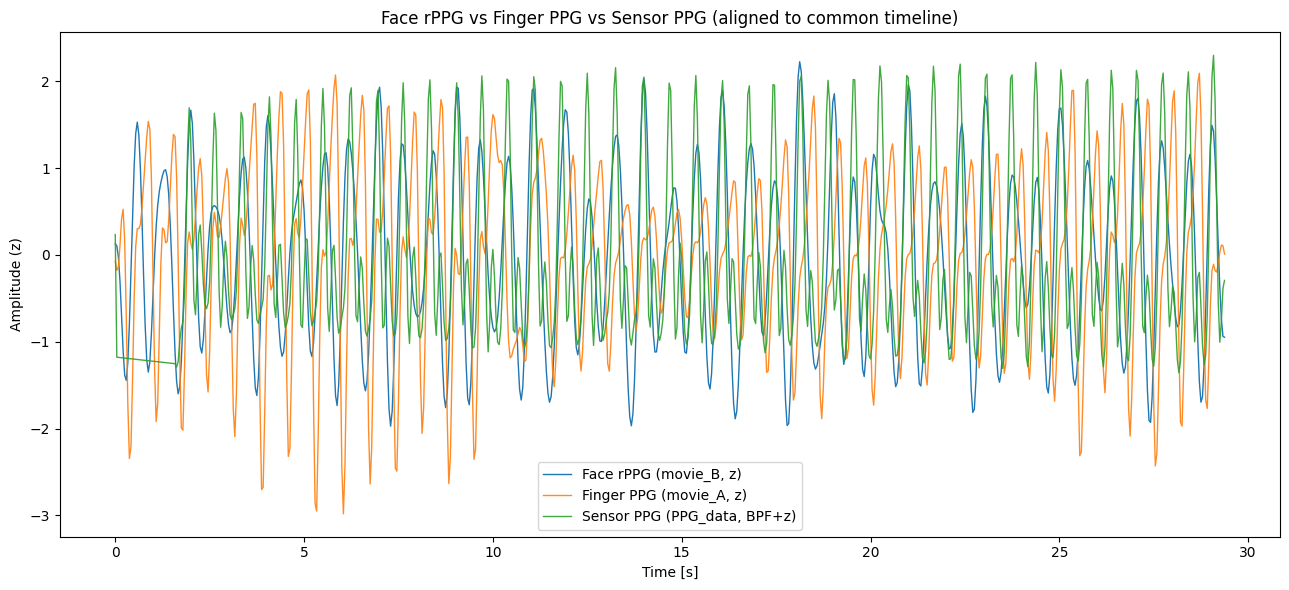

In [ ]:
# ====== 3系統（顔rPPG・指PPG・センサPPG）を同一時間軸で重ね描き ======
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# 既存と同じ関数（なければ定義）
def bandpass_butter(x, fs, low=0.5, high=4.0, order=3):
    if fs <= 0:
        return x
    nyq = 0.5 * fs
    low_n = max(1e-6, low / nyq)
    high_n = min(0.999, high / nyq)
    b, a = butter(order, [low_n, high_n], btype='band')
    return filtfilt(b, a, x)

def robust_fs(t):
    dt = np.diff(t)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if dt.size == 0: return 0.0
    return 1.0 / np.median(dt)

# ====== パス ======
TEST_DIR = "/content/drive/Shareddrives/MuraolabExchange-6th/Taiki Yuma/研究/DMD_mode/test_data"
FACE_CSV = os.path.join(TEST_DIR, "movie_B01_face_ppg.csv")   # 1列：np.savetxt
FING_CSV = os.path.join(TEST_DIR, "movie_A01_finger_ppg.csv") # 2列：time_sec,value
SENS_CSV = os.path.join(TEST_DIR, "PPG_data_01.csv")          # 2列：elapsed_time_sec,sensor_value

# ====== 顔（movie_B4）— 1列, すでにBPF済を想定 → z正規化のみ ======
face_arr = pd.read_csv(FACE_CSV, header=None).values.squeeze().astype(float)
face_z   = (face_arr - np.mean(face_arr)) / (np.std(face_arr) + 1e-8)

# 顔のサンプルレート（不明なら 30 Hz）
try:
    FACE_FS = float(fps) if ('fps' in globals() and fps and fps > 0) else 30.0
except:
    FACE_FS = 30.0
t_face = np.arange(len(face_z)) / FACE_FS

# ====== 指（movie_A4）— time,value（BPF済想定）→ z正規化 ======
df_fing = pd.read_csv(FING_CSV)
t_fing  = pd.to_numeric(df_fing.iloc[:, 0], errors="coerce").to_numpy()
y_fing  = pd.to_numeric(df_fing.iloc[:, 1], errors="coerce").to_numpy()
mask_f  = np.isfinite(t_fing) & np.isfinite(y_fing)
t_fing  = t_fing[mask_f]
y_fing  = y_fing[mask_f]
y_fing_z = (y_fing - np.mean(y_fing)) / (np.std(y_fing) + 1e-8)

# ====== センサ（PPG_data_4）— time, raw → BPF(0.5–4Hz) → z正規化 ======
df_sens = pd.read_csv(SENS_CSV)
# 列名のゆらぎ対策
cols = {c.lower().strip(): c for c in df_sens.columns}
t_col = cols.get("elapsed_time_sec", None)
v_col = cols.get("sensor_value", None)
if t_col is None or v_col is None:
    raise ValueError(f"センサCSVの列名が想定と異なります: {list(df_sens.columns)}\n必要: elapsed_time_sec, sensor_value")

t_sens  = pd.to_numeric(df_sens[t_col], errors="coerce").to_numpy()
x_raw   = pd.to_numeric(df_sens[v_col], errors="coerce").to_numpy()
mask_s  = np.isfinite(t_sens) & np.isfinite(x_raw)
t_sens  = t_sens[mask_s]
x_raw   = x_raw[mask_s]

FS_SENS = robust_fs(t_sens)
x_bp    = bandpass_butter(x_raw - np.mean(x_raw), fs=FS_SENS, low=0.5, high=4.0, order=3)
x_bp_z  = (x_bp - np.mean(x_bp)) / (np.std(x_bp) + 1e-8)

# ====== 共通時間軸を作成（顔のFsで、3系列の共通オーバーラップ区間） ======
t_start = max(t_face[0], t_fing[0], t_sens[0])
t_end   = min(t_face[-1], t_fing[-1], t_sens[-1])
if t_end <= t_start:
    raise RuntimeError("3系列のオーバーラップ区間がありません。ファイルと時間軸を確認してください。")

t_common = np.arange(t_start, t_end, 1.0/FACE_FS)

# 指とセンサを t_common に補間、顔はそのまま補間（境界外は除いているためOK）
face_plot = np.interp(t_common, t_face, face_z)
fing_plot = np.interp(t_common, t_fing, y_fing_z)
sens_plot = np.interp(t_common, t_sens, x_bp_z)

# ====== プロット ======
plt.figure(figsize=(13,6))
plt.plot(t_common, face_plot, label="Face rPPG (movie_B, z)", linewidth=1.0)
plt.plot(t_common, fing_plot, label="Finger PPG (movie_A, z)", linewidth=1.0, alpha=0.9)
plt.plot(t_common, sens_plot, label="Sensor PPG (PPG_data, BPF+z)", linewidth=1.0, alpha=0.9)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude (z)")
plt.title("Face rPPG vs Finger PPG vs Sensor PPG (aligned to common timeline)")
plt.legend()
plt.tight_layout()
plt.show()

[Face vs Sensor]  best NCC=0.112 at lag=-600 ms (Sensorlag)
[Finger vs Sensor] best NCC=0.116 at lag=-467 ms (Sensorlag)


/tmp/ipython-input-4189885288.py:71: UserWarning: Glyph 36933 (\N{CJK UNIFIED IDEOGRAPH-9045}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4189885288.py:71: UserWarning: Glyph 12428 (\N{HIRAGANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


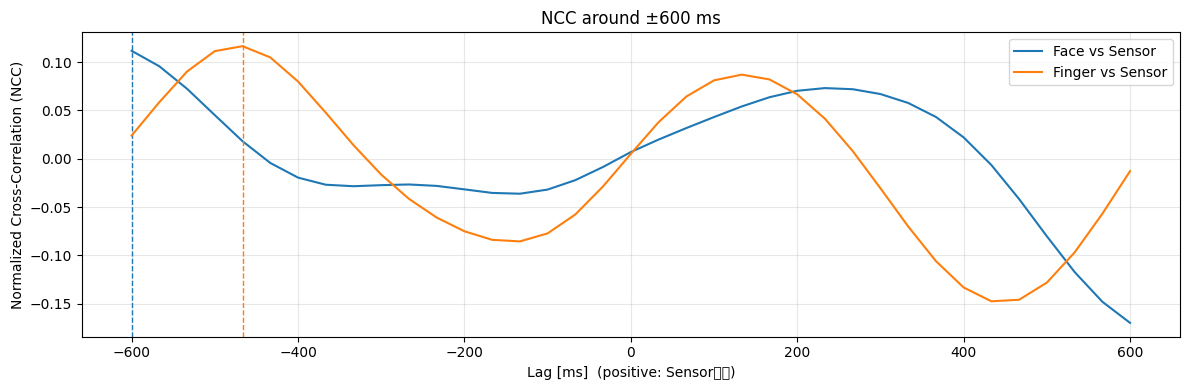

In [ ]:
# ====== 追記：相互相関係数（NCC）で類似度を評価（Face↔Sensor, Finger↔Sensor） ======
import numpy as np
import matplotlib.pyplot as plt

def norm_xcorr(x, y, fs, max_lag_sec=0.6):
    """
    正規化相互相関（NCC）を計算し、[-max_lag_sec, +max_lag_sec] の範囲で返す。
    返り値:
        lags_sec : ラグ配列 [s]（y が x に対して遅れる(+)、進む(-)）
        ncc      : 各ラグでの相互相関係数 [-1, 1]
        best_lag_sec : NCC最大時のラグ [s]
        best_ncc     : NCC最大値
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = min(len(x), len(y))
    x = x[:n]; y = y[:n]

    # ゼロ平均・単位分散（相関係数の前提）
    x = (x - np.mean(x)) / (np.std(x) + 1e-12)
    y = (y - np.mean(y)) / (np.std(y) + 1e-12)

    # 有限ラグに制限
    max_lag = int(round(max_lag_sec * fs))
    lags = np.arange(-max_lag, max_lag + 1)
    ncc = np.empty_like(lags, dtype=float)

    # 端点処理：そのラグで重なる部分だけで相関係数を計算
    for i, k in enumerate(lags):
        if k >= 0:
            xs = x[k:]
            ys = y[:n - k]
        else:
            xs = x[:n + k]
            ys = y[-k:]
        # 相関係数（ピアソン）と同じ計算
        denom = (len(xs) * 1.0)
        # ここでは xs, ys は既に z 正規化済みなので単純平均の内積/長さでOK
        ncc[i] = float(np.dot(xs, ys) / denom)

    # 最大値とそのラグ
    idx = int(np.argmax(ncc))
    best_lag = lags[idx] / fs
    best_val = ncc[idx]
    return lags / fs, ncc, best_lag, best_val

# パラメータ：探索ラグ
MAX_LAG_SEC = 0.6   # 必要に応じて調整（±600msなど）

# Face vs Sensor
lags_f_s, ncc_f_s, lagbest_f_s, nccbest_f_s = norm_xcorr(face_plot, sens_plot, fs=FACE_FS, max_lag_sec=MAX_LAG_SEC)
print(f"[Face vs Sensor]  best NCC={nccbest_f_s:.3f} at lag={lagbest_f_s*1000:.0f} ms "
      f"({'Sensordelay' if lagbest_f_s>0 else 'Sensorlag' if lagbest_f_s<0 else 'naw'})")

# Finger vs Sensor
lags_g_s, ncc_g_s, lagbest_g_s, nccbest_g_s = norm_xcorr(fing_plot, sens_plot, fs=FACE_FS, max_lag_sec=MAX_LAG_SEC)
print(f"[Finger vs Sensor] best NCC={nccbest_g_s:.3f} at lag={lagbest_g_s*1000:.0f} ms "
      f"({'Sensordelay' if lagbest_g_s>0 else 'Sensorlag' if lagbest_g_s<0 else 'naw'})")

# ====== 相互相関係数のプロット ======
plt.figure(figsize=(12,4))
plt.plot(lags_f_s*1000, ncc_f_s, label="Face vs Sensor")
plt.axvline(lagbest_f_s*1000, color='tab:blue', linestyle='--', linewidth=1)
plt.plot(lags_g_s*1000, ncc_g_s, label="Finger vs Sensor")
plt.axvline(lagbest_g_s*1000, color='tab:orange', linestyle='--', linewidth=1)
plt.xlabel("Lag [ms]  (positive: Sensor遅れ)")
plt.ylabel("Normalized Cross-Correlation (NCC)")
plt.title(f"NCC around ±{int(MAX_LAG_SEC*1000)} ms")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


[GCC-PHAT] 窓長=5.0s, ホップ=1.0s, 最大遅延=±300ms
  推定 τ (median): -49.6 ms
  推定 τ (mean±std): -62.7 ± 54.2 ms
  採用率: 100.0%  (閾値: r_peak ≥ 0.15, coherence ≥ 0.3)


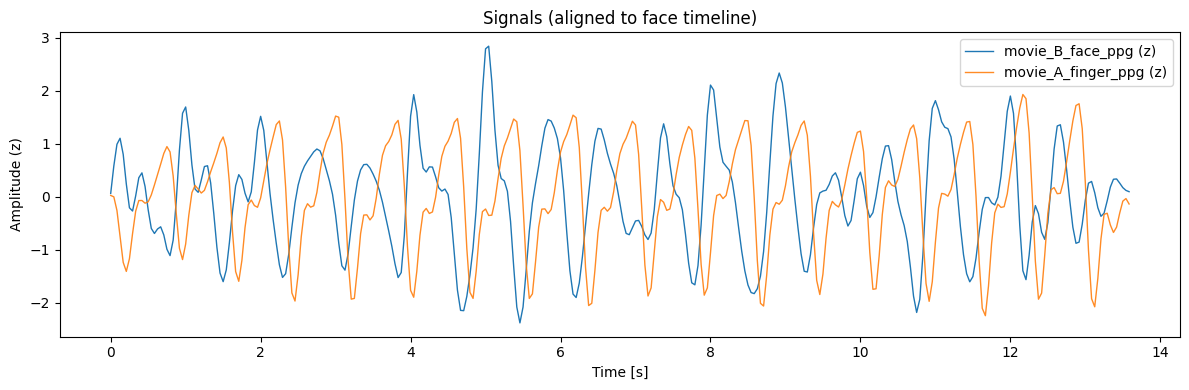

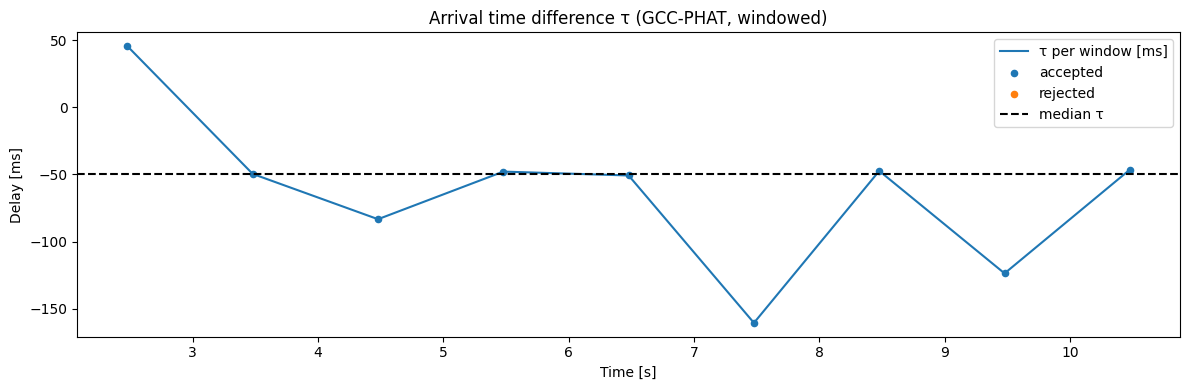

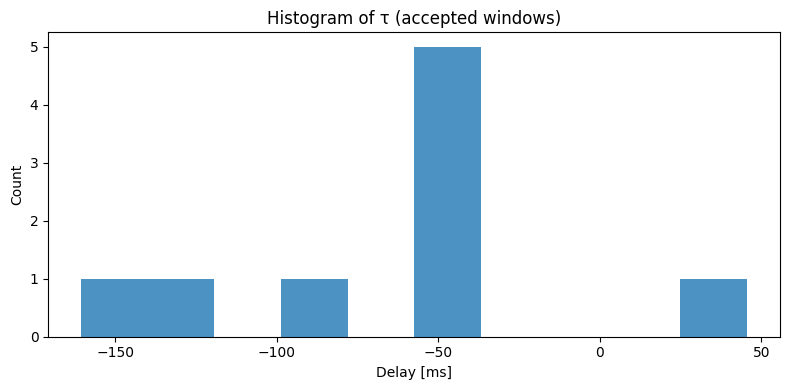

窓ごとの推定結果を保存しました: /content/drive/Shareddrives/MuraolabExchange-6th/Taiki Yuma/研究/DMD_mode/test_data/movieB_face__movieA_finger__delay_windows.csv


In [ ]:
# ===========================================
# GCC-PHAT による到達時差推定（スライディング窓＋品質ゲート付き）
# 入力:
#   - movie_B_face_ppg.csv （1列, 既にBPF済みの顔rPPG）
#   - movie_A_finger_ppg.csv（2列: time_sec, value, 既にBPF済みの指PPG）
# 出力:
#   - τ(秒) を窓ごとに推定し、品質ゲートを通過した値の統計を表示
#   - 可視化（信号, τの時系列, ヒストグラム）
#   - 窓ごとの結果を CSV 保存
# ===========================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import coherence, welch
from numpy.fft import rfft, irfft

# ---- パラメータ ----
TEST_DIR = "/content/drive/Shareddrives/MuraolabExchange-6th/Taiki Yuma/研究/DMD_mode/test_data"
FACE_CSV = os.path.join(TEST_DIR, "movie_B_face_ppg.csv")    # 1列
FING_CSV = os.path.join(TEST_DIR, "movie_A_finger_ppg.csv")  # time,value
# サンプリング関連
CSV_FS_FACE = float(fps) if 'fps' in globals() and fps and fps > 0 else 30.0   # 顔csvのFs（動画FPSに準拠）
LOW_HZ, HIGH_HZ = 0.7, 4            # コヒーレンスの評価帯域（HR中心）
# 窓設定
WIN_SEC = 5.0                          # 推奨: 5秒（安定）
HOP_SEC = 1.0                          # 推奨: 1秒（オーバーラップ可）
MAX_LAG_SEC = 0.30                     # 生理的に見込める最大遅延（±）
# 品質ゲート（経験値。必要に応じて調整）
MIN_RPEAK = 0.15                       # 相互相関ピークの高さ（0〜1目安）
MIN_COH   = 0.30                       # コヒーレンス（0〜1）

# ---- ユーティリティ ----
def gcc_phat_window(x, y, fs, max_lag_sec=0.3):
    """
    ゼロ平均・単位分散で受け取り、GCC-PHATの相互相関列(正規化済)とラグ配列を返す。
    返り値:
        lags (s), cc (相互相関), tau_hat (s), r_peak (ピーク高さ)
    """
    n = 1
    L = len(x) + len(y)
    while n < L: n <<= 1
    # 実FFTで十分
    X = rfft(x, n)
    Y = rfft(y, n)
    R = X * np.conj(Y)
    R /= (np.abs(R) + 1e-12)  # PHAT重み
    cc = irfft(R, n)
    # 原点合わせ（負ラグを後半へ回す）
    cc = np.concatenate((cc[-(n//2):], cc[:n//2]))
    lags = np.arange(-n//2, n//2) / fs

    # 探索範囲を制限
    mask = (np.abs(lags) <= max_lag_sec)
    lags_m = lags[mask]
    cc_m   = cc[mask]

    # ピーク検出（放物線補間）
    k = int(np.argmax(cc_m))
    if 0 < k < len(cc_m)-1:
        y0, y1, y2 = cc_m[k-1], cc_m[k], cc_m[k+1]
        denom = (2*(y0 - 2*y1 + y2) + 1e-12)
        delta = (y0 - y2) / denom
        tau_hat = lags_m[k] + (delta / (2*fs))
        r_peak = float(y1 - 0.25*(y0 - y2)*delta)  # 補間後ピーク高さ近似
    else:
        tau_hat = lags_m[k]
        r_peak = float(cc_m[k])

    # ピーク高さを [0,1] 近辺にスケール（念のため）
    # 相互相関の最大絶対値で正規化
    if np.max(np.abs(cc_m)) > 1e-9:
        r_peak /= float(np.max(np.abs(cc_m)))

    return lags_m, cc_m, float(tau_hat), float(r_peak)

def ms_coherence(x, y, fs, band=(0.7,1.7)):
    f, Cxy = coherence(x, y, fs=fs, nperseg=min(len(x), 512))
    sel = (f >= band[0]) & (f <= band[1])
    if np.sum(sel) < 2:
        return 0.0
    return float(np.mean(Cxy[sel]))

# ---- 入力の読み込み ----
# 顔: 1列, BPF済 → z正規化
face_arr = pd.read_csv(FACE_CSV, header=None).values.squeeze().astype(float)
face_z = (face_arr - np.mean(face_arr)) / (np.std(face_arr) + 1e-8)
t_face = np.arange(len(face_z)) / CSV_FS_FACE

# 指: time,value の2列, BPF済 → z正規化
df_fing = pd.read_csv(FING_CSV)
t_fing  = df_fing.iloc[:,0].values.astype(float)
y_fing  = df_fing.iloc[:,1].values.astype(float)
y_fing_z = (y_fing - np.mean(y_fing)) / (np.std(y_fing) + 1e-8)

# ---- 時間軸を顔側に合わせて指を補間（厳密同期）----
# 共有区間のマスク（念のためオーバーラップ範囲に限定）
t0 = max(t_face[0], t_fing[0])
t1 = min(t_face[-1], t_fing[-1])
mask_face = (t_face >= t0) & (t_face <= t1)
t_common  = t_face[mask_face]
# 指を t_common に線形補間
y_fing_sync = np.interp(t_common, t_fing, y_fing_z)

# 顔も同じ区間に切り出し
face_sync = face_z[mask_face]

# ---- スライディング窓で τ を推定 ----
fs = CSV_FS_FACE  # 顔のサンプリング周波数
win = int(round(WIN_SEC * fs))
hop = int(round(HOP_SEC * fs))
win = max(win, 8); hop = max(hop, 1)

taus = []
rpeaks = []
cohs = []
t_mid = []   # 各窓の中心時刻
flags = []   # True=採用, False=棄却

for s in range(0, len(t_common) - win + 1, hop):
    e = s + win
    xf = face_sync[s:e]
    yf = y_fing_sync[s:e]
    # 念のため z 正規化（窓ごと）
    xf = (xf - np.mean(xf)) / (np.std(xf) + 1e-8)
    yf = (yf - np.mean(yf)) / (np.std(yf) + 1e-8)

    # GCC-PHAT
    lags_m, cc_m, tau_hat, r_peak = gcc_phat_window(xf, yf, fs=fs, max_lag_sec=MAX_LAG_SEC)
    # コヒーレンス（HR帯）
    coh = ms_coherence(xf, yf, fs=fs, band=(LOW_HZ, HIGH_HZ))

    taus.append(tau_hat)
    rpeaks.append(r_peak)
    cohs.append(coh)
    t_mid.append(0.5*(t_common[s] + t_common[e-1]))

    # 品質ゲート
    ok = (r_peak >= MIN_RPEAK) and (coh >= MIN_COH)
    flags.append(bool(ok))

taus   = np.array(taus, dtype=float)
rpeaks = np.array(rpeaks, dtype=float)
cohs   = np.array(cohs, dtype=float)
t_mid  = np.array(t_mid, dtype=float)
flags  = np.array(flags, dtype=bool)

# ---- 集計（ゲート通過のみ）----
if np.any(flags):
    tau_med = float(np.median(taus[flags]))
    tau_mean = float(np.mean(taus[flags]))
    tau_std  = float(np.std(taus[flags]))
    accept_rate = float(np.mean(flags))  # 採用率
else:
    tau_med = np.nan; tau_mean = np.nan; tau_std = np.nan; accept_rate = 0.0

print(f"[GCC-PHAT] 窓長={WIN_SEC:.1f}s, ホップ={HOP_SEC:.1f}s, 最大遅延=±{int(MAX_LAG_SEC*1000)}ms")
print(f"  推定 τ (median): {tau_med*1000:.1f} ms")
print(f"  推定 τ (mean±std): {tau_mean*1000:.1f} ± {tau_std*1000:.1f} ms")
print(f"  採用率: {accept_rate*100:.1f}%  (閾値: r_peak ≥ {MIN_RPEAK}, coherence ≥ {MIN_COH})")

# ---- 可視化 ----
plt.figure(figsize=(12,4))
plt.plot(t_common, face_sync, label="movie_B_face_ppg (z)", lw=1.0)
plt.plot(t_common, y_fing_sync, label="movie_A_finger_ppg (z)", lw=1.0, alpha=0.9)
plt.xlabel("Time [s]"); plt.ylabel("Amplitude (z)")
plt.title("Signals (aligned to face timeline)")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(12,4))
plt.plot(t_mid, taus*1000, label="τ per window [ms]")
plt.scatter(t_mid[flags], (taus[flags]*1000), s=20, c='tab:blue', label="accepted")
plt.scatter(t_mid[~flags], (taus[~flags]*1000), s=20, c='tab:orange', label="rejected")
plt.axhline((tau_med*1000) if np.isfinite(tau_med) else 0, ls='--', c='k', label="median τ")
plt.xlabel("Time [s]"); plt.ylabel("Delay [ms]")
plt.title("Arrival time difference τ (GCC-PHAT, windowed)")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
bins = max(10, int(np.sqrt(max(1, np.sum(flags)))))  # Freedman–Diaconis風の簡易
plt.hist((taus[flags]*1000) if np.any(flags) else [], bins=bins, color='tab:blue', alpha=0.8)
plt.xlabel("Delay [ms]"); plt.ylabel("Count")
plt.title("Histogram of τ (accepted windows)")
plt.tight_layout(); plt.show()

# ---- 保存（窓ごとの結果）----
out_name = "movieB_face__movieA_finger__delay_windows.csv"
out_path = os.path.join(TEST_DIR, out_name)
df_out = pd.DataFrame({
    "t_mid_sec": t_mid,
    "tau_sec": taus,
    "tau_ms": taus*1000,
    "r_peak_norm": rpeaks,
    "coherence_0p7_1p7Hz": cohs,
    "accepted": flags.astype(int)
})
df_out.to_csv(out_path, index=False, encoding="utf-8")
print("窓ごとの推定結果を保存しました:", out_path)

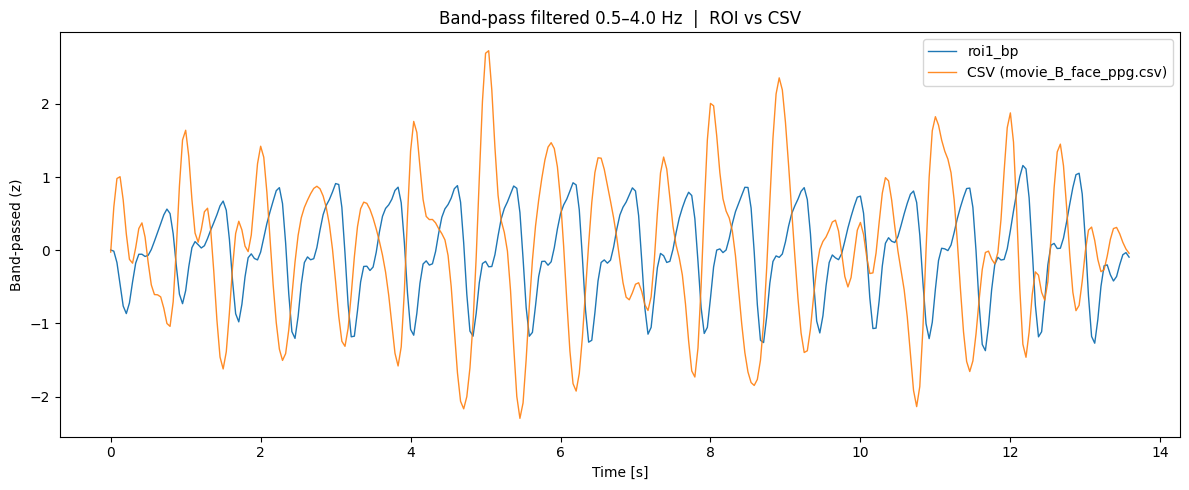

In [ ]:
# ====== 追記：CSVの波形を同じグラフに重ね描き ======
# CSV例: 1列の波形（ヘッダ有無どちらでもOK）。時刻列がない想定。
CSV_PATH = os.path.join(BASE_DIR, "movie_B_face_ppg.csv")  # ←重ねたいCSVのパスに変更
CSV_FS   = float(fps) if fps and fps > 0 else 30.0         # ←CSVのサンプルレート（不明なら動画FPSに合わせる）

def load_csv_onecol(path):
    try:
        arr = pd.read_csv(path, header=None).values.squeeze()
    except Exception:
        arr = pd.read_csv(path).iloc[:,0].values.squeeze()
    return np.asarray(arr, dtype=float)

csv_sig = load_csv_onecol(CSV_PATH)

# 同じ帯域でBPF→z正規化
csv_sig = csv_sig - np.nanmean(csv_sig)
csv_sig = np.nan_to_num(csv_sig)
csv_bp  = bandpass_butter(csv_sig, fs=CSV_FS, low=LOW_HZ, high=HIGH_HZ, order=3)
csv_bp  = (csv_bp - np.mean(csv_bp)) / (np.std(csv_bp) + 1e-8)

# 時間軸を作成（CSVは等間隔サンプリングの想定）
t_csv = np.arange(len(csv_bp)) / CSV_FS

# 既存の roi1_bp と長さを揃える（短い方に合わせる）
first_col = [c for c in df.columns if c.startswith("roi")][0] + "_bp"
y_roi = np.asarray(df[first_col], dtype=float)
t_roi = np.asarray(df["time_sec"], dtype=float)

L = min(len(y_roi), len(csv_bp))
y_roi_plot = y_roi[:L]
t_roi_plot = t_roi[:L]
csv_bp_plot = csv_bp[:L]    # 時間軸も L に合わせる
t_csv_plot  = t_csv[:L]     # ほぼ t_roi と一致するはず（FSが同じなら）

# ====== 同じ図に重ねて表示 ======
plt.figure(figsize=(12,5))
plt.plot(t_roi_plot, y_roi_plot, label=f"{first_col}", linewidth=1.0)
plt.plot(t_csv_plot, csv_bp_plot, label=f"CSV ({os.path.basename(CSV_PATH)})", linewidth=1.0, alpha=0.9)
plt.xlabel("Time [s]")
plt.ylabel("Band-passed (z)")
plt.title(f"Band-pass filtered {LOW_HZ:.1f}–{HIGH_HZ:.1f} Hz  |  ROI vs CSV")
plt.legend()
plt.tight_layout()
plt.show()

FPS: 24.00, Number of Frames: 327, Width: 1080, Height: 1920


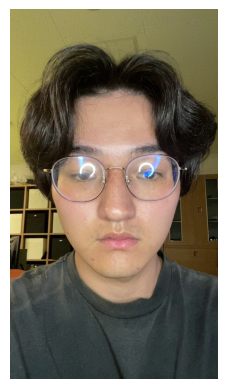

In [ ]:
# 動画ファイルのパス
BASE_DIR = "/content/drive/Shareddrives/MuraolabExchange-6th/Taiki Yuma/研究/DMD_mode/movie"
file = "movie_B.mov"
video_path = os.path.join(BASE_DIR, file)

# 動画の読み込み
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"動画を開けませんでした: {video_path}")

# 動画の基本情報
fps = cap.get(cv2.CAP_PROP_FPS) or 0.0
num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)

print(f"FPS: {fps:.2f}, Number of Frames: {num_frames}, Width: {width}, Height: {height}")

# 1フレーム目の取得
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ret, frame = cap.read()

if not ret or frame is None:
    cap.release()
    raise RuntimeError("フレームの読み込みに失敗しました")

# BGR -> RGB 変換して表示（Matplotlib を使用）
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.imshow(frame_rgb)
plt.axis('off')
plt.show()

# リソース解放（ヘッドレスなので destroyAllWindows は不要）
cap.release()

--2025-09-05 11:46:19--  https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28104 (27K) [text/plain]
Saving to: ‘deploy.prototxt’

deploy.prototxt     100%[===================>]  27.45K  --.-KB/s    in 0s      

2025-09-05 11:46:19 (117 MB/s) - ‘deploy.prototxt’ saved [28104/28104]

--2025-09-05 11:46:19--  https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_sa

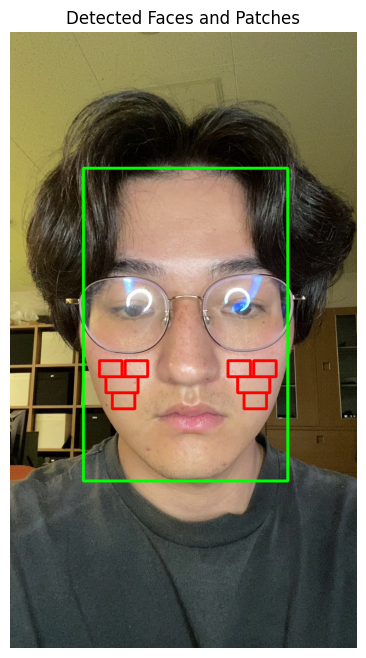

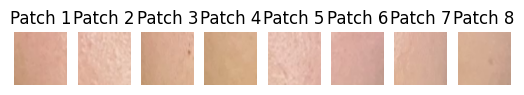

In [ ]:
# Load the pre-trained face detection model
prototxt = 'deploy.prototxt'
model = 'res10_300x300_ssd_iter_140000.caffemodel'
net = cv2.dnn.readNetFromCaffe(prototxt, model)

# 動画ファイルのパス
BASE_DIR = "/content/drive/Shareddrives/MuraolabExchange-6th/Taiki Yuma/研究/DMD_mode/movie"
file = "movie_B.mov"
video_path = os.path.join(BASE_DIR, file)
cap = cv2.VideoCapture(video_path)

# Read the first frame
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ret, frame = cap.read()
cap.release()

if not ret:
    raise Exception("Failed to read video frame.")

# Convert the image to blob
(h, w) = frame.shape[:2]
blob = cv2.dnn.blobFromImage(cv2.resize(frame, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))

# Perform face detection
net.setInput(blob)
detections = net.forward()

# Draw bounding boxes around detected faces
for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]
    if confidence > 0.5:
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        (startX, startY, endX, endY) = box.astype("int")

        # Draw bounding box for face
        cv2.rectangle(frame, (startX, startY), (endX, endY), (0, 255, 0), 8)  # Green color, thickness 4

        # Facial patches configuration relative to the detected face
        regions = [
            {'shift_x': 50, 'shift_y': 600, 'width': 70, 'height': 50},
            {'shift_x': 130, 'shift_y': 600, 'width': 70, 'height': 50},
            {'shift_x': 70, 'shift_y': 650, 'width': 100, 'height': 50},
            {'shift_x': 90, 'shift_y': 700, 'width': 70, 'height': 50},
            {'shift_x': 450, 'shift_y': 600, 'width': 70, 'height': 50},
            {'shift_x': 530, 'shift_y': 600, 'width': 70, 'height': 50},
            {'shift_x': 480, 'shift_y': 650, 'width': 100, 'height': 50},
            {'shift_x': 500, 'shift_y': 700, 'width': 70, 'height': 50},

        ]

        # Extract facial patches
        patches = []
        for region in regions:
            shift_x = region['shift_x']
            shift_y = region['shift_y']
            width = region['width']
            height = region['height']

            # Adjust coordinates based on shifts and sizes relative to the detected face
            x1 = max(0, startX + shift_x)
            y1 = max(0, startY + shift_y)
            x2 = min(w, x1 + width)
            y2 = min(h, y1 + height)

            # Crop the patch
            patch = frame[y1:y2, x1:x2]

            # Resize to 100x100 if necessary
            patch = cv2.resize(patch, (100, 100))

            patches.append((patch, (x1, y1, x2, y2)))  # Save patch and its bounding box

        # Draw red boxes around the selected patches
        for _, (x1, y1, x2, y2) in patches:
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 8)  # Red color, thickness 4

        # Display the frame with detected faces and patches
        plt.figure(figsize=(12, 8))  # Adjust the figure size as needed
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title("Detected Faces and Patches")
        plt.axis('off')
        plt.show()

        # Display extracted patches
        for i, (patch, _) in enumerate(patches):
            plt.subplot(1, len(patches), i+1)
            plt.imshow(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
            plt.title(f"Patch {i+1}")
            plt.axis('off')

        plt.show()
        break  # Exit loop after processing the first detected face
